In [1]:
import numpy as np
import pandas as pd



In [2]:
# Cargamos el dataset
data = pd.read_csv('HousingData.csv')
print(data.head())  

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [3]:
# El indice de pobreza es la columna 13
x1 = data.iloc[:,12]
# El impuesto de la vivienda es la columna 10
x2 = data.iloc[:,9]
# El valor medio de la vivienda es la columna 14
y = data.iloc[:,13]

# Normalizamos los datos
x1 = (x1 - x1.mean()) / x1.std()
x2 = (x2 - x2.mean()) / x2.std()
y = (y - y.mean()) / y.std()


print(x1.head())
print(x2.head())
print(y.head())


0   -1.074500
1   -0.491952
2   -1.207534
3   -1.360173
4   -1.025488
Name: LSTAT, dtype: float64
0   -0.665949
1   -0.986353
2   -0.986353
3   -1.105022
4   -1.105022
Name: TAX, dtype: float64
0    0.159528
1   -0.101424
2    1.322937
3    1.181589
4    1.486032
Name: MEDV, dtype: float64


In [4]:
# Resolvemos por cambio de variable el la regresion multilineal
def cambio_de_variable(x1, x2, y):
    z1 = x1
    z2 = x2
    z3 = x1**2
    z4 = x2**2
    z5 = x1*x2
    
    return z1, z2, z3, z4, z5, y


In [5]:
z1, z2, z3, z4, z5, y = cambio_de_variable(x1, x2, y)

In [6]:

# Definimos la funcion de Gradiente Descent para el cambio de variable
def GradienteDescent(z1, z2, z3, z4, z5, y):
    N = len(y)
    Z = np.c_[np.ones(N), z1, z2, z3, z4, z5]
    w = np.dot(np.dot(np.linalg.inv(np.dot(Z.T,Z)),Z.T),y)
    
    return w


In [7]:
# ENCONTRAMOS LOS PARAMETROS DE LA REGRESION MULTILINEAL
w = GradienteDescent(z1, z2, z3, z4, z5, y)
print(w)

[-0.38391694 -0.9560461  -0.10636734  0.30850001  0.18910398 -0.20758943]


In [8]:
# Calculamos el error cuadratico medio
N = len(y)
Z = np.c_[np.ones(N), z1, z2, z3, z4, z5]
y_pred = np.dot(Z,w)
error = np.sum((y - y_pred)**2)/N
print(error)

0.32779318943048336


In [9]:
# Modelamos la regresion deshaciendo el cambio de variable y ajustando al modelo propuesto
# y = w0 + w1*x1 + w2*x2 + w3*x1^2 + w4*x2^2 + w5*x1*x2

def Regresion(z1, z2, z3, z4, z5, w):
    y = w[0] + w[1]*z1 + w[2]*z2 + w[3]*z3 + w[4]*z4 + w[5]*z5
    
    return y

In [10]:
y_hat = Regresion(z1, z2, z3, z4, z5, w)

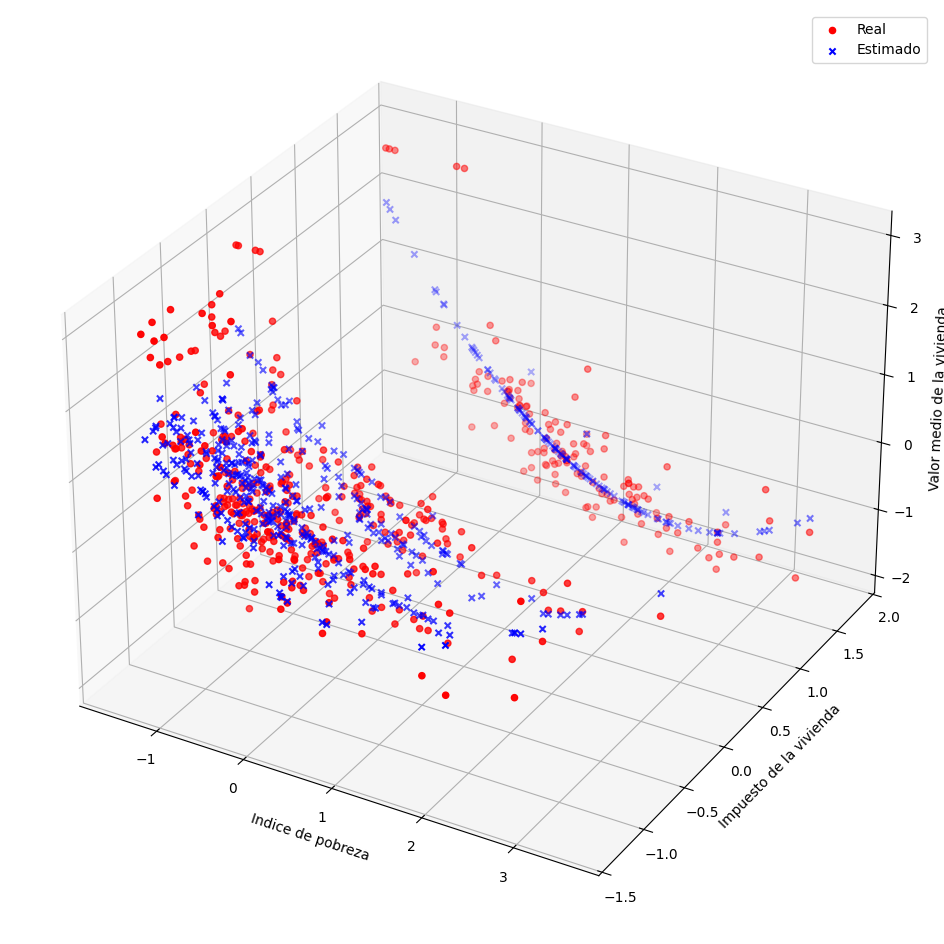

In [21]:
# Graficamos los resultados

import matplotlib.pyplot as plt
fig = plt.figure(1, figsize=(12, 12))
fig.clf()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y, c='r', marker='o', label='Real')
ax.scatter(x1, x2, y_hat, c='b', marker='x', label='Estimado')
ax.set_xlabel('Indice de pobreza')
ax.set_ylabel('Impuesto de la vivienda')
ax.set_zlabel('Valor medio de la vivienda')
plt.legend(loc='upper right')
plt.show()


In [12]:
#calculamos el coeficiente de determinacion
R2 = 1 - np.sum((y - y_hat)**2)/np.sum((y - y.mean())**2)
print(f'Coeficiente de determinacion: {R2}')

Coeficiente de determinacion: 0.6715577151449017


In [13]:
# la prediccion del valor de la vivienda para un indice de pobreza de 0.1 y un impuesto de 300
x1_pred = 0.1
x2_pred = 300

# Normalizamos los datos
x1_pred = (x1_pred - x1.mean()) / x1.std()
x2_pred = (x2_pred - x2.mean()) / x2.std()


z1_pred, z2_pred, z3_pred, z4_pred, z5_pred, y_pred = cambio_de_variable(x1_pred, x2_pred, y)
y_hat_pred = Regresion(z1_pred, z2_pred, z3_pred, z4_pred, z5_pred, w)


print(f'El valor de la vivienda para un indice de pobreza de 0.1 y un impuesto de 300 es: {y_hat_pred}')




El valor de la vivienda para un indice de pobreza de 0.1 y un impuesto de 300 es: 16980.744313164003


In [14]:
# Graficamos la di